# Comprensión de los datos: EDA del dataset de radiografías

Este notebook documenta la etapa de **Comprensión de los Datos** de CRISP-DM para el proyecto de clasificación de radiografías de tórax en las clases `NORMAL` y `PNEUMONIA`.

El análisis se ejecuta desde la raíz del proyecto y reutiliza las funciones de `src/data/make_dataset.py`. No entrena modelos ni modifica el dataset original.

Este notebook describe el dataset crudo `data/raw/chest_xray/` con su estructura original `train`/`val`/`test`. El reparto experimental 70/15/15 (train 4.099, validation 879 y test 878) no se genera aquí: se crea en la etapa de preparación de datos y es el que se utiliza para el modelado.

## Objetivo del EDA

El objetivo es describir la composición, calidad y variabilidad del dataset antes de la preparación y el modelado. Se analizarán distribución de clases, dimensiones, tamaños, formatos, corrupción, duplicados y ejemplos visuales.

In [15]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "data" / "make_dataset.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("No se encontró la raíz del proyecto con src/data/make_dataset.py.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.make_dataset import (
    DATA_DIR,
    _hash_file,
    collect_image_records,
    get_dataset_summary,
    plot_sample_images,
    save_eda_figures,
    validate_dataset_structure,
)

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "chest_xray"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"

print(f"Dataset: {DATA_PATH}")
print(f"Existe: {DATA_PATH.exists()}")
print(f"Ruta configurada por el proyecto: {DATA_DIR}")
assert DATA_PATH.exists(), "No se encontró el dataset. Ejecute dvc pull data/raw/chest_xray.dvc."

Dataset: D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumonia\data\raw\chest_xray
Existe: True
Ruta configurada por el proyecto: D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumonia\data\raw\chest_xray


## Validación de la estructura

La estructura esperada del dataset crudo contiene `train`, `val` y `test`, cada uno con `NORMAL` y `PNEUMONIA`. Estos subconjuntos son los que vienen con el dataset original y solo se describen en este EDA; el reparto experimental utilizado para el modelado se crea después, en la preparación de datos.

In [16]:
validation = validate_dataset_structure(DATA_PATH)
validation_table = pd.DataFrame(validation).T
validation_table.index.name = "split"
display(validation_table)

records = collect_image_records(DATA_PATH)
summary = get_dataset_summary(DATA_PATH)
print(f"Total de imágenes: {summary['total_images']:,}")
print(f"Filas de metadata recopiladas: {len(records):,}")
display(records.head())

,exists,labels,missing_labels
split,,,
train,True,"[NORMAL, PNEUMONIA]",[]
val,True,"[NORMAL, PNEUMONIA]",[]
test,True,"[NORMAL, PNEUMONIA]",[]


Total de imágenes: 5,856
Filas de metadata recopiladas: 5,856


,split,label,path,filename,extension,file_size_bytes,width,height,mode
0,test,NORMAL,D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumon...,IM-0001-0001.jpeg,.jpeg,252680,1857,1317,L
1,test,NORMAL,D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumon...,IM-0003-0001.jpeg,.jpeg,329189,2111,1509,L
2,test,NORMAL,D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumon...,IM-0005-0001.jpeg,.jpeg,408620,2031,1837,L
3,test,NORMAL,D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumon...,IM-0006-0001.jpeg,.jpeg,252275,1663,1326,L
4,test,NORMAL,D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumon...,IM-0007-0001.jpeg,.jpeg,408508,2053,1818,L


## Distribución de imágenes por split y clase

Se construye una tabla de conteos a partir de `records`. Las cifras corresponden a la estructura original del dataset crudo (`data/raw/chest_xray/`) y son puramente descriptivas; no constituyen el reparto experimental usado en el entrenamiento.

In [17]:
counts = records.pivot_table(index="split", columns="label", values="path", aggfunc="count", fill_value=0)
for label in ["NORMAL", "PNEUMONIA"]:
    if label not in counts.columns:
        counts[label] = 0
counts = counts[["NORMAL", "PNEUMONIA"]]
counts["Total"] = counts.sum(axis=1)
counts.loc["Total"] = counts.sum(axis=0)
display(counts.astype(int))

figures = save_eda_figures(records, FIGURES_PATH)
sample_figures = plot_sample_images(records, FIGURES_PATH)
print("Figuras generadas:")
for name, path in {**figures, **sample_figures}.items():
    print(f"- {name}: {path}")

label,NORMAL,PNEUMONIA,Total
split,,,
test,234,390,624
train,1341,3875,5216
val,8,8,16
Total,1583,4273,5856


Figuras generadas:
- distribution: D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumonia\reports\figures\dataset_distribution.png
- sizes: D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumonia\reports\figures\file_size_distribution.png
- dimensions: D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumonia\reports\figures\image_dimensions.png
- NORMAL: D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumonia\reports\figures\sample_normal.png
- PNEUMONIA: D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumonia\reports\figures\sample_pneumonia.png


## Análisis porcentual de clases y desbalance

La primera tabla muestra el porcentaje de cada clase dentro de cada split de la estructura cruda. La segunda muestra el peso de cada split de la estructura cruda sobre el total del dataset.

In [18]:
split_counts = records.groupby(["split", "label"]).size().unstack(fill_value=0)
class_percentages = split_counts.div(split_counts.sum(axis=1), axis=0).mul(100).round(2)
class_percentages["Total"] = split_counts.sum(axis=1)
print("Porcentaje de cada clase dentro de cada split:")
display(class_percentages[["NORMAL", "PNEUMONIA", "Total"]])

split_percentages = records.groupby("split").size().to_frame("images")
split_percentages["percentage_of_dataset"] = (split_percentages["images"] / len(records) * 100).round(2)
print("Peso de cada split sobre el dataset completo:")
display(split_percentages)

overall_class_percentages = (records["label"].value_counts(normalize=True).mul(100).round(2).rename("percentage"))
print("Porcentaje global por clase:")
display(overall_class_percentages.to_frame())
print("Diferencia global de cantidad entre PNEUMONIA y NORMAL:", int(split_counts.sum()["PNEUMONIA"] - split_counts.sum()["NORMAL"]))

Porcentaje de cada clase dentro de cada split:


label,NORMAL,PNEUMONIA,Total
split,,,
test,37.50,62.50,624
train,25.71,74.29,5216
val,50.00,50.00,16


Peso de cada split sobre el dataset completo:


,images,percentage_of_dataset
split,,
test,624,10.66
train,5216,89.07
val,16,0.27


Porcentaje global por clase:


,percentage
label,
PNEUMONIA,72.97
NORMAL,27.03


Diferencia global de cantidad entre PNEUMONIA y NORMAL: 2690


## Análisis de dimensiones de las imágenes

Se analizan las columnas `width` y `height`, además de las combinaciones más frecuentes.

In [19]:
dimension_records = records.dropna(subset=["width", "height"]).copy()
dimension_summary = dimension_records[["width", "height"]].agg(["min", "max", "mean", "median"]).round(2).T
display(dimension_summary)

frequent_dimensions = (
    dimension_records.groupby(["width", "height"], as_index=False)
    .size()
    .rename(columns={"size": "images"})
    .sort_values("images", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
display(frequent_dimensions)
print(f"Registros con dimensiones válidas: {len(dimension_records):,} de {len(records):,}")
print("Las dimensiones variables justifican el redimensionamiento posterior a un tamaño común de entrada.")

,min,max,mean,median
width,384.0,2916.0,1327.88,1281.0
height,127.0,2713.0,970.69,888.0


,width,height,images
0,1072,648,7
1,1008,704,7
2,992,608,6
3,1216,872,6
4,1080,728,6
5,992,592,6
6,1184,792,5
7,1152,664,5
8,1136,680,5
9,1088,712,5


Registros con dimensiones válidas: 5,856 de 5,856
Las dimensiones variables justifican el redimensionamiento posterior a un tamaño común de entrada.


## Análisis de tamaño de archivos

Se reportan valores en bytes y en megabytes para facilitar la lectura.

,bytes,megabytes
min,5441.00,0.0052
max,2414342.00,2.3025
mean,211148.02,0.2014
median,95839.00,0.0914


,min,max,mean,median
split,,,,
test,0.0188,0.6903,0.1208,0.0872
train,0.0052,2.3025,0.2111,0.0918
val,0.0470,0.5056,0.1806,0.1385


Figura de distribución de tamaños:


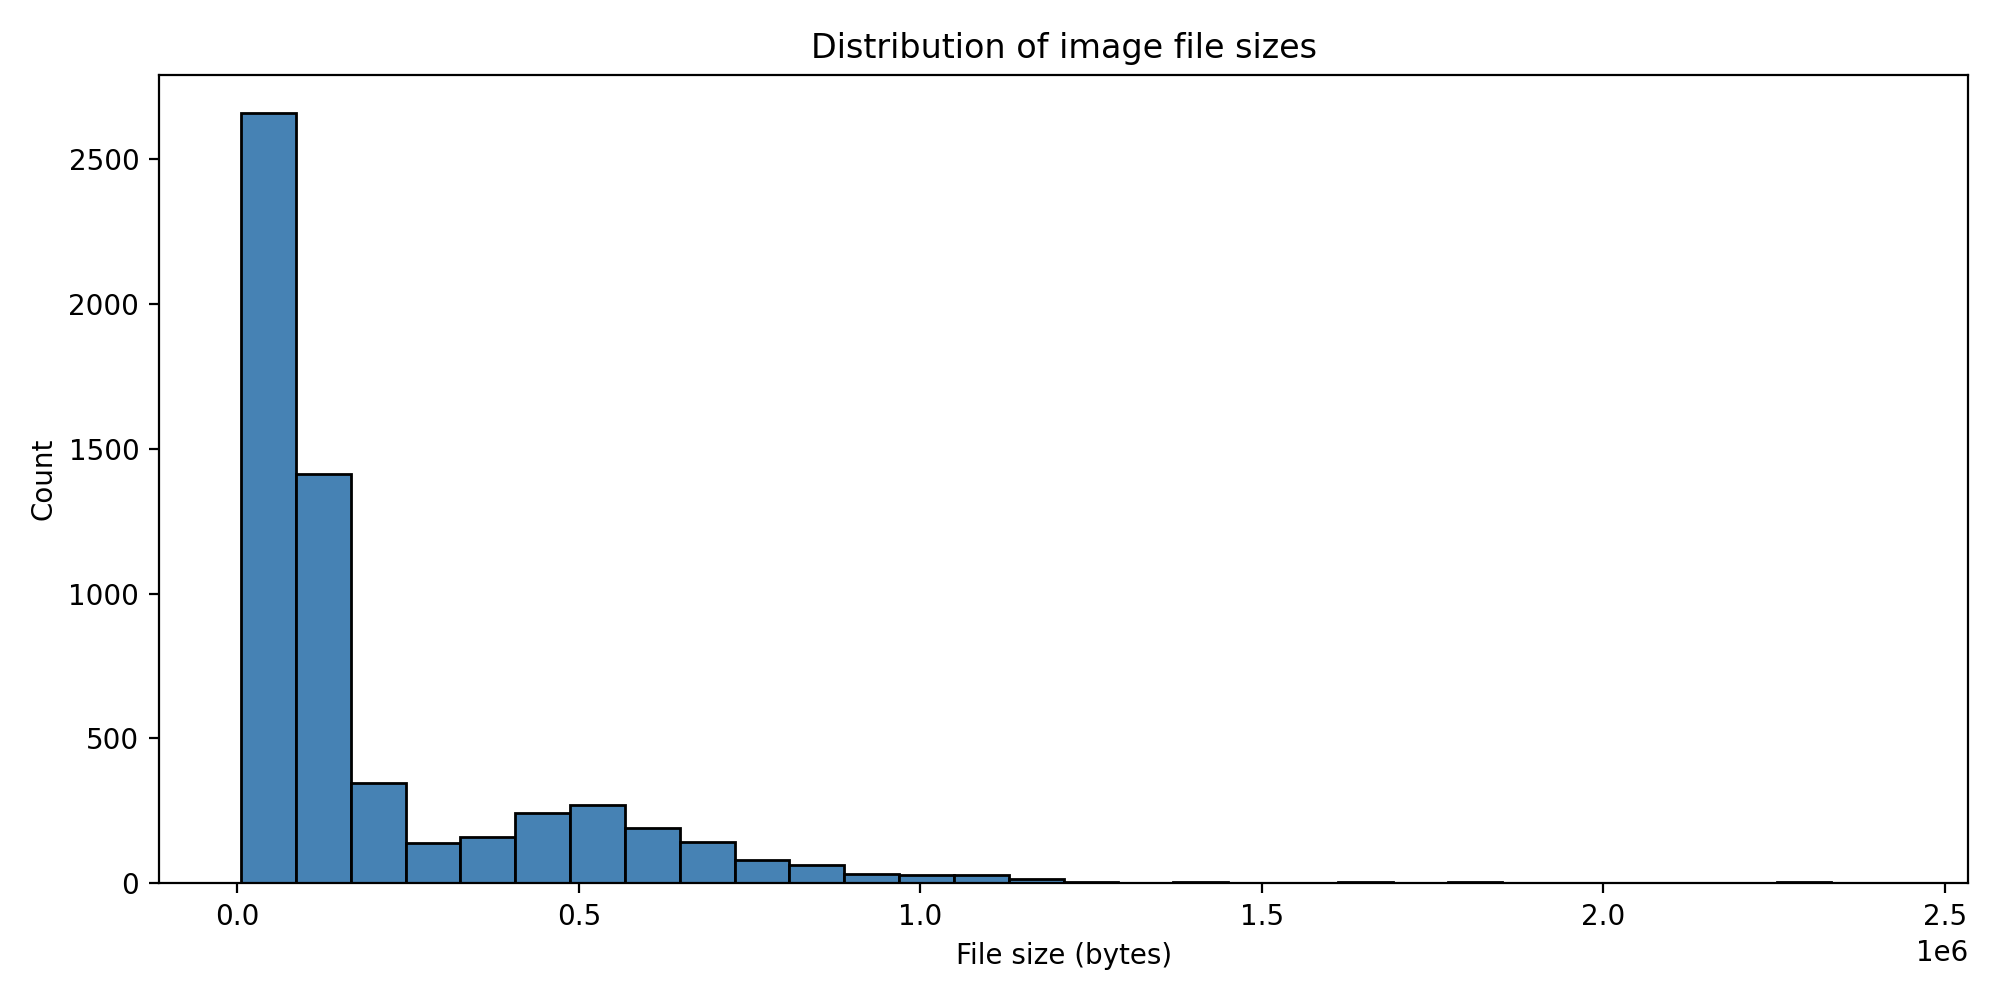

In [20]:
size_summary = records["file_size_bytes"].agg(["min", "max", "mean", "median"]).to_frame("bytes").round(2)
size_summary["megabytes"] = (size_summary["bytes"] / (1024 ** 2)).round(4)
display(size_summary)

size_by_split = records.assign(size_mb=records["file_size_bytes"] / (1024 ** 2)).groupby("split")["size_mb"].agg(["min", "max", "mean", "median"]).round(4)
display(size_by_split)

from IPython.display import Image as DisplayImage
print("Figura de distribución de tamaños:")
display(DisplayImage(filename=str(FIGURES_PATH / "file_size_distribution.png")))

## Extensiones y modo de las imágenes

Estas frecuencias se calculan directamente desde la metadata recopilada; no se asume homogeneidad antes de comprobarla.

In [21]:
extension_frequency = records["extension"].value_counts().rename_axis("extension").to_frame("images")
extension_frequency["percentage"] = (extension_frequency["images"] / len(records) * 100).round(2)
mode_frequency = records["mode"].value_counts(dropna=False).rename_axis("mode").to_frame("images")
mode_frequency["percentage"] = (mode_frequency["images"] / len(records) * 100).round(2)
print("Extensiones:")
display(extension_frequency)
print("Modos de imagen:")
display(mode_frequency)

Extensiones:


,images,percentage
extension,,
.jpeg,5856,100.0


Modos de imagen:


,images,percentage
mode,,
L,5573,95.17
RGB,283,4.83


## Detección de imágenes corruptas

`get_dataset_summary` verifica cada archivo con Pillow y devuelve las rutas que no pueden validarse.

In [22]:
corrupt_images = [Path(path) for path in summary["corrupt_images"]]
corrupt_count = len(corrupt_images)
corrupt_percentage = corrupt_count / len(records) * 100
print(f"Imágenes corruptas: {corrupt_count:,} de {len(records):,} ({corrupt_percentage:.2f}%)")
if corrupt_images:
    display(pd.DataFrame({"path": [str(path) for path in corrupt_images]}))
else:
    print("Hallazgo: no se detectaron imágenes corruptas.")

Imágenes corruptas: 0 de 5,856 (0.00%)
Hallazgo: no se detectaron imágenes corruptas.


## Detección y análisis de duplicados

Se reutiliza `_hash_file`, la función SHA-256 existente en `make_dataset.py`. Un grupo representa un contenido idéntico presente en dos o más rutas.

In [23]:
hash_rows = []
for _, row in records.iterrows():
    path = Path(row["path"])
    try:
        file_hash = _hash_file(path)
    except OSError:
        continue
    hash_rows.append({"hash": file_hash, "path": str(path), "split": row["split"], "label": row["label"]})

hash_records = pd.DataFrame(hash_rows)
duplicate_groups = hash_records.groupby("hash").filter(lambda group: len(group) > 1)
groups_by_hash = duplicate_groups.groupby("hash")
number_of_duplicate_groups = groups_by_hash.ngroups
number_of_duplicate_paths = len(duplicate_groups) - number_of_duplicate_groups

print(f"Grupos de contenido duplicado: {number_of_duplicate_groups:,}")
print(f"Rutas pertenecientes a grupos duplicados: {len(duplicate_groups):,}")
print(f"Rutas duplicadas adicionales respecto a una ruta representante: {number_of_duplicate_paths:,}")

duplicate_split_counts = duplicate_groups.groupby("split").size().rename("duplicate_paths").to_frame()
display(duplicate_split_counts)

def crosses_splits(group):
    return group["split"].nunique() > 1

cross_split_groups = [group for _, group in groups_by_hash if crosses_splits(group)]
within_split_groups = [group for _, group in groups_by_hash if not crosses_splits(group)]
print(f"Grupos duplicados que cruzan splits: {len(cross_split_groups):,}")
print(f"Grupos duplicados contenidos en un solo split: {len(within_split_groups):,}")

if cross_split_groups:
    cross_split_table = pd.concat(cross_split_groups, ignore_index=True)
    display(cross_split_table.sort_values(["hash", "split"]))
else:
    print("No se detectaron duplicados exactos entre train, val y test.")

Grupos de contenido duplicado: 30
Rutas pertenecientes a grupos duplicados: 62
Rutas duplicadas adicionales respecto a una ruta representante: 32


,duplicate_paths
split,
test,12
train,50


Grupos duplicados que cruzan splits: 0
Grupos duplicados contenidos en un solo split: 30
No se detectaron duplicados exactos entre train, val y test.


## Visualización de ejemplos NORMAL y PNEUMONIA

Se utilizan las muestras generadas por `plot_sample_images`, sin duplicar la lógica de lectura y composición de figuras.

NORMAL


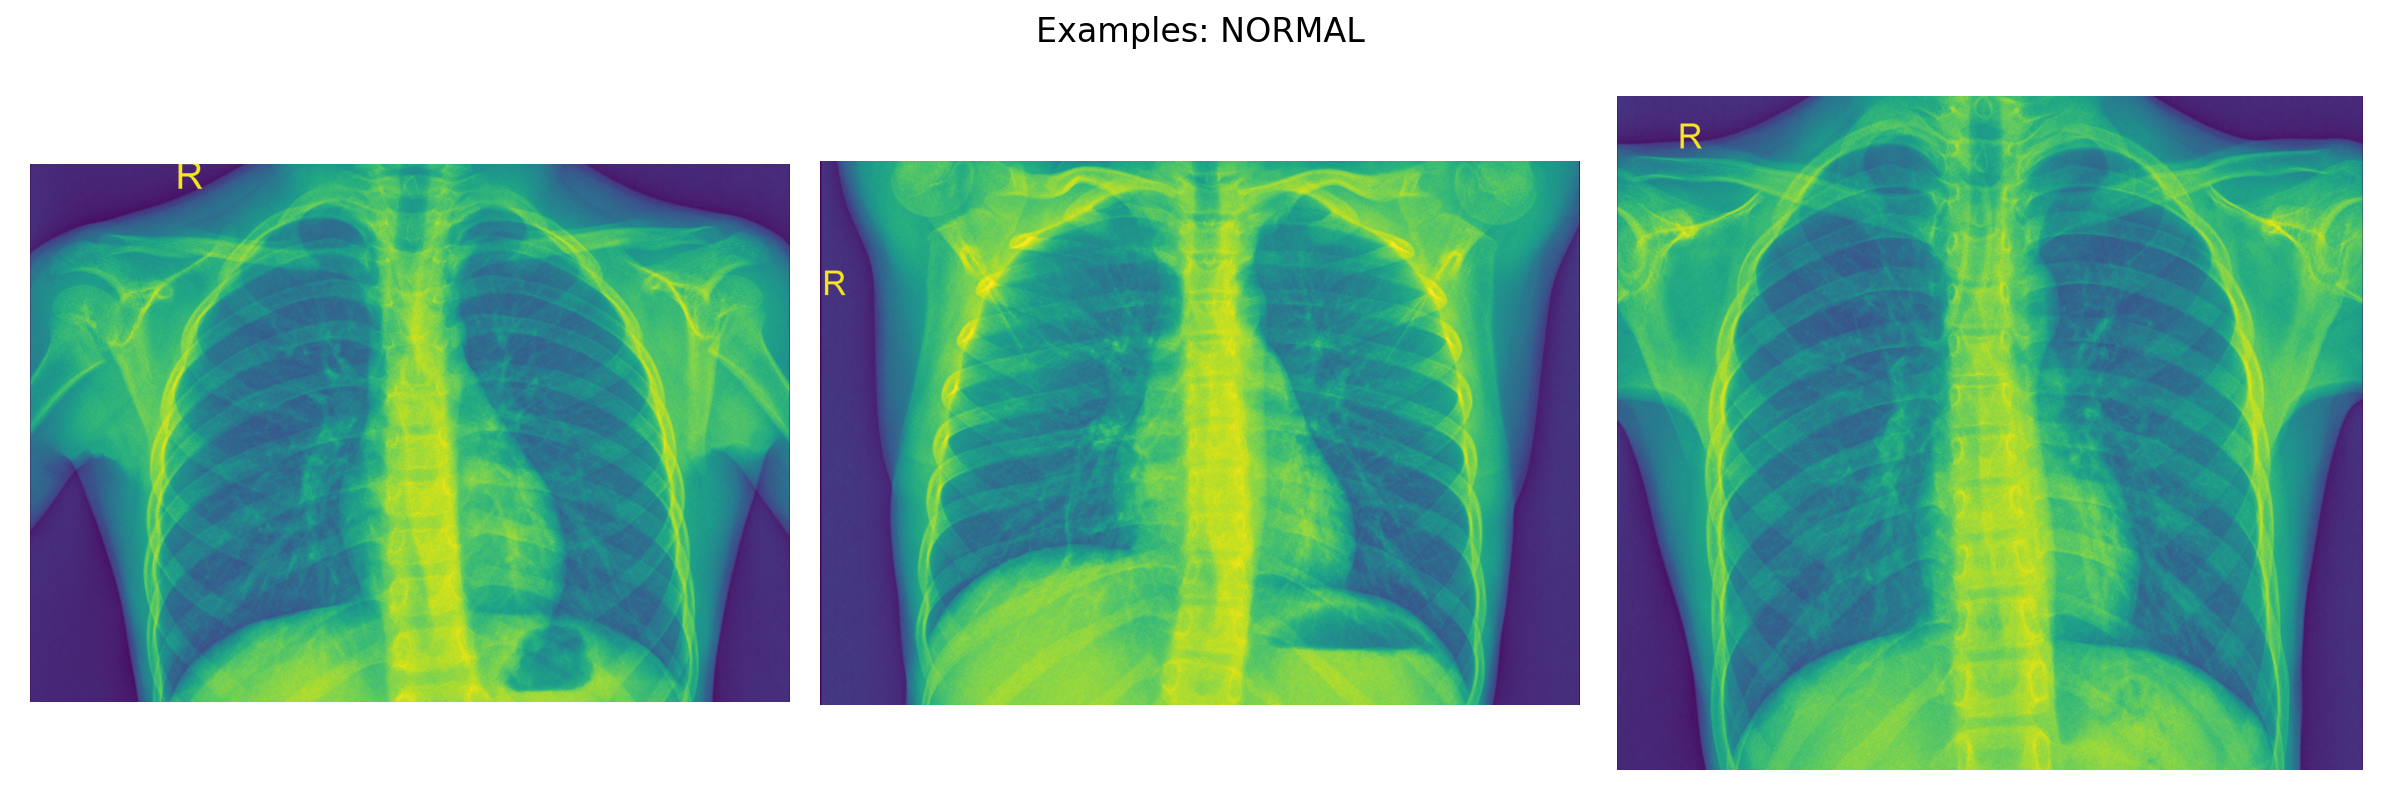

PNEUMONIA


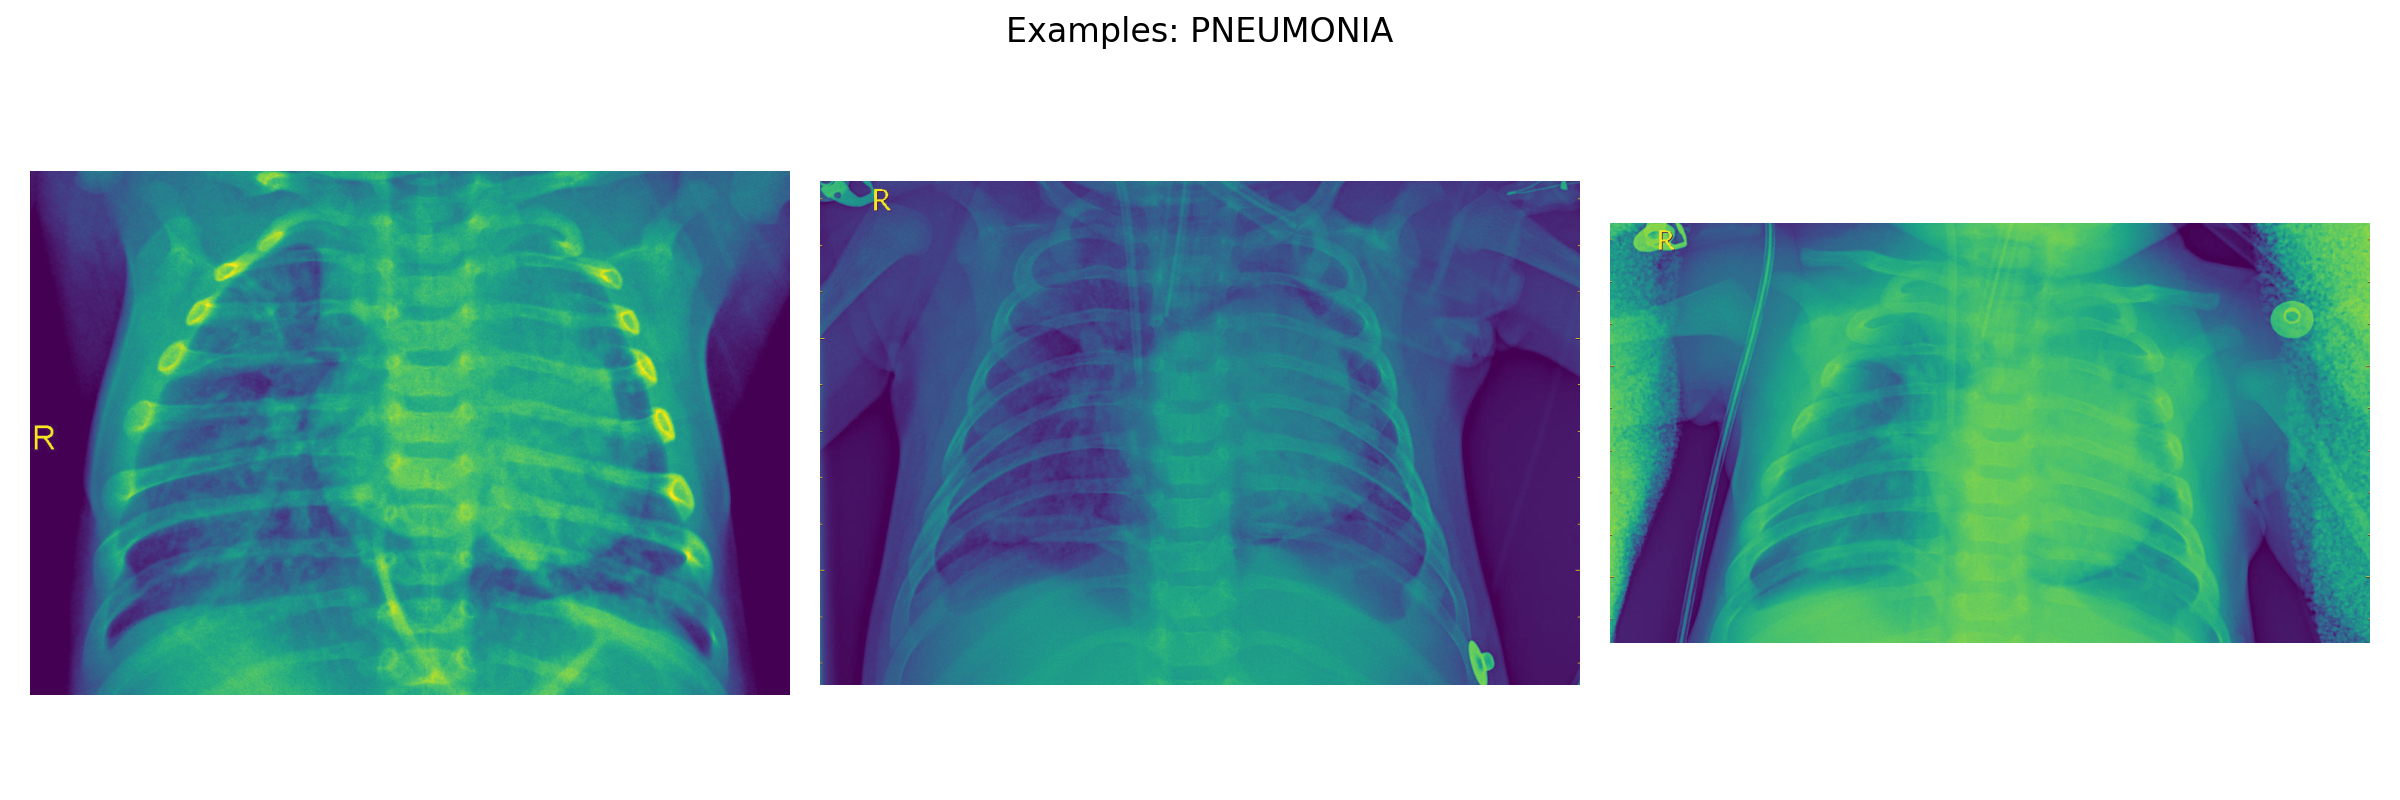

Todas las figuras se guardan en: D:\CIENCIA_DATOS\Modulo_6\Code\proyecto-neumonia\reports\figures


In [24]:
sample_figures = plot_sample_images(records, FIGURES_PATH, max_per_class=3)
for label, path in sample_figures.items():
    print(label)
    display(DisplayImage(filename=str(path)))

print("Todas las figuras se guardan en:", FIGURES_PATH)

## Figuras generadas

Se comprueba la existencia de las cinco figuras solicitadas.

In [25]:
expected_figures = [
    "dataset_distribution.png",
    "file_size_distribution.png",
    "image_dimensions.png",
    "sample_normal.png",
    "sample_pneumonia.png",
]
figure_status = pd.DataFrame({
    "figure": expected_figures,
    "exists": [(FIGURES_PATH / name).exists() for name in expected_figures],
})
display(figure_status)
assert figure_status["exists"].all(), "No se generaron todas las figuras esperadas."

,figure,exists
0,dataset_distribution.png,True
1,file_size_distribution.png,True
2,image_dimensions.png,True
3,sample_normal.png,True
4,sample_pneumonia.png,True


## Hallazgos principales

- El dataset contiene 5.856 imágenes distribuidas en `train`, `val` y `test`; las tablas anteriores muestran los conteos exactos por clase.
- `PNEUMONIA` es la clase mayoritaria en el conjunto global y especialmente en el `train` original de `data/raw/chest_xray/`. El `val` original contiene solo 16 imágenes (8 por clase); esta cifra describe el dataset crudo y no se utiliza como validación final del modelado.
- El experimento de modelado no usa directamente esta estructura cruda: en la etapa de preparación de datos se genera el reparto estratificado 70/15/15 (`data/interim/stratified_split_70_15_15.csv`, train 4.099, validation 879 y test 878) sin duplicados entre los tres conjuntos.
- Las dimensiones y los tamaños de archivo presentan variabilidad, por lo que no se puede asumir una entrada homogénea antes del preprocesamiento.
- Las extensiones y modos se verifican mediante sus frecuencias observadas, no mediante una suposición previa.
- La validación de Pillow permite identificar explícitamente las imágenes corruptas.
- Los duplicados se analizan por contenido SHA-256 y se separan entre duplicados internos de un split y duplicados que cruzan splits.
- Las figuras EDA y las muestras visuales quedan guardadas en `reports/figures/`.

In [26]:
print(f"Total de imágenes: {len(records):,}")
print(f"Distribución global: {records['label'].value_counts().to_dict()}")
print(f"Imágenes corruptas: {corrupt_count:,}")
print(f"Grupos duplicados: {number_of_duplicate_groups:,}")
print(f"Grupos duplicados entre splits: {len(cross_split_groups):,}")
print(f"Dimensión mínima observada: {dimension_records[['width', 'height']].min().to_dict()}")
print(f"Dimensión máxima observada: {dimension_records[['width', 'height']].max().to_dict()}")
print(f"Tamaño mediano en MB: {size_summary.loc['median', 'megabytes']:.4f}")

Total de imágenes: 5,856
Distribución global: {'PNEUMONIA': 4273, 'NORMAL': 1583}
Imágenes corruptas: 0
Grupos duplicados: 30
Grupos duplicados entre splits: 0
Dimensión mínima observada: {'width': 384, 'height': 127}
Dimensión máxima observada: {'width': 2916, 'height': 2713}
Tamaño mediano en MB: 0.0914


## Conclusiones del EDA

El dataset está listo para continuar al preprocesamiento porque su estructura esperada fue validada y las imágenes pueden describirse mediante la metadata recopilada durante el EDA. Las dimensiones variables requieren redimensionamiento a un tamaño común antes de alimentar las redes convolucionales.

El desbalance hacia `PNEUMONIA` debe considerarse al interpretar Accuracy y al seleccionar métricas de evaluación. La especificidad y la sensibilidad deben analizarse conjuntamente. Este EDA describe la estructura cruda: el `val` original de 16 imágenes no se utiliza para la selección de modelos, porque en la preparación de datos se crea una partición experimental estratificada 70/15/15 con validation de 879 imágenes y test de 878.

Los duplicados deben distinguirse correctamente: los duplicados dentro de un mismo split no constituyen por sí solos una fuga entre entrenamiento y evaluación; los duplicados cruzando splits sí serían una señal de riesgo. El análisis anterior informa explícitamente cuál de los dos casos está presente.

## Implicaciones para la preparación y el modelado

- Aplicar conversión a RGB, redimensionamiento y normalización de forma reproducible.
- Crear el reparto 70/15/15 con `create_stratified_split_manifest` (semilla 42, estratificado por clase y sin duplicados por contenido entre conjuntos), registrado en `data/interim/stratified_split_70_15_15.csv` (train 4.099, validation 879 y test 878).
- Aplicar augmentation únicamente al conjunto de entrenamiento; no transformar artificialmente `validation` ni `test`.
- Mantener las etiquetas `NORMAL = 0` y `PNEUMONIA = 1` de manera consistente.
- Reportar Recall/Sensitivity, Specificity, Precision, F1, Accuracy, ROC-AUC y Balanced Accuracy, no solo una métrica.
- Considerar estrategias de tratamiento del desbalance en una etapa posterior, documentando cualquier decisión experimental.
- Seleccionar el modelo únicamente con las métricas de `validation` y reservar `test` para la evaluación final del modelo ganador.
- Mantener la verificación de duplicados como control de calidad antes de incorporar nuevas imágenes.